## Name: Pradum Bisen
## Class And Batch: C2_B1_03

In [97]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

In [99]:
df = pd.read_csv("titanic.csv")

In [101]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [103]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [105]:
df.shape

(891, 12)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [109]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [111]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [113]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [117]:
df["Embarked"] = df["Embarked"].replace("S", 0)
df["Embarked"] = df["Embarked"].replace("C", 1)
df["Embarked"] = df["Embarked"].replace("Q", 2)

In [119]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0.0


In [123]:
df["Sex"] = df["Sex"].replace("male", 0)
df["Sex"] = df["Sex"].replace("female", 1)

In [125]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0.0


In [223]:
df["Age"].fillna(df["Age"].median(), inplace = True)

In [225]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace = True)

In [139]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [141]:
df.drop("Cabin", axis = 1, inplace = True)

In [143]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0.0


In [145]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [147]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0


In [149]:
df.duplicated().sum()

116

In [151]:
df.drop_duplicates(inplace=True)

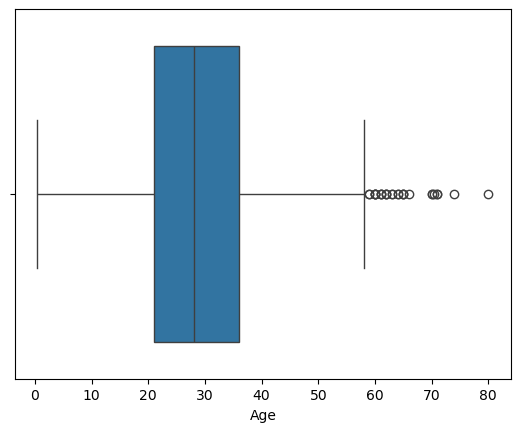

In [153]:
sns.boxplot(x = df["Age"])
plt.show()

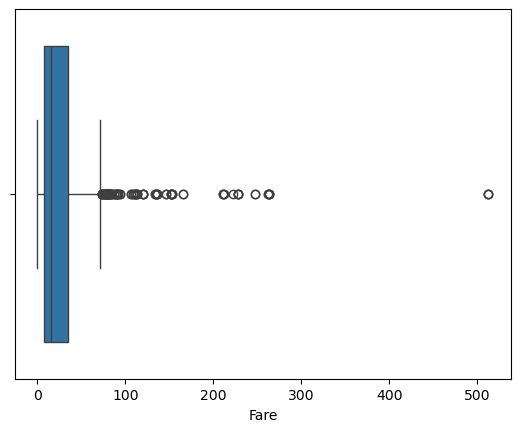

In [155]:
sns.boxplot(x = df["Fare"])
plt.show()

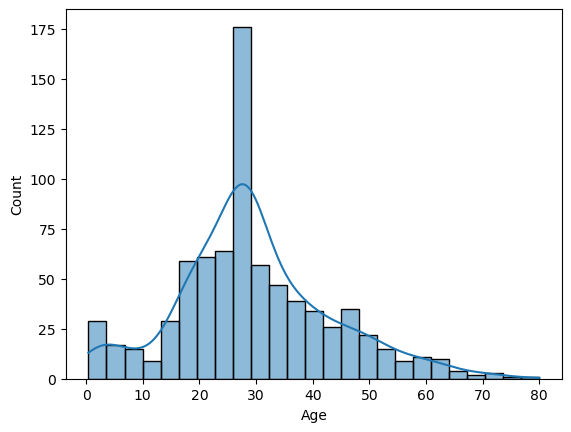

In [174]:
sns.histplot(df["Age"], kde = True)
plt.show()

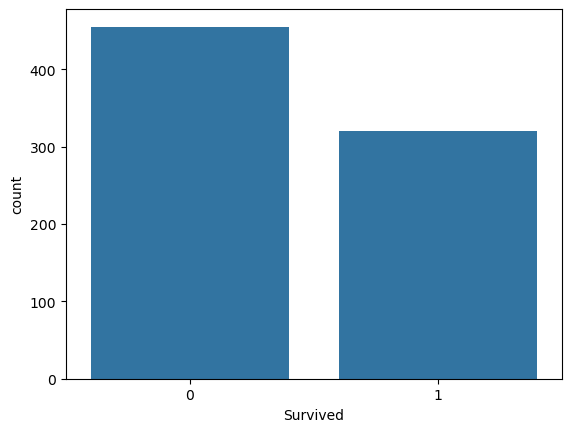

In [176]:
sns.countplot(x = "Survived", data = df)
plt.show()

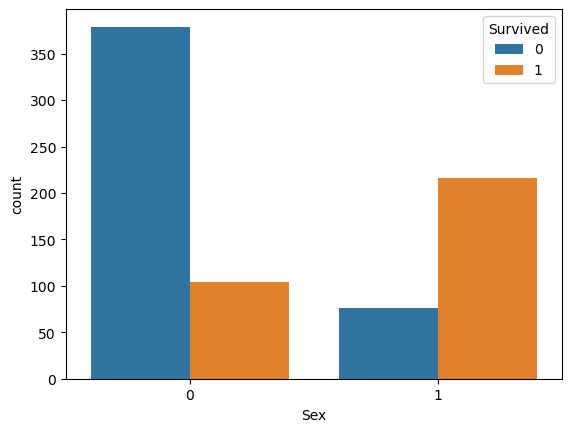

In [178]:
sns.countplot(x = "Sex", hue = "Survived", data = df)
plt.show()

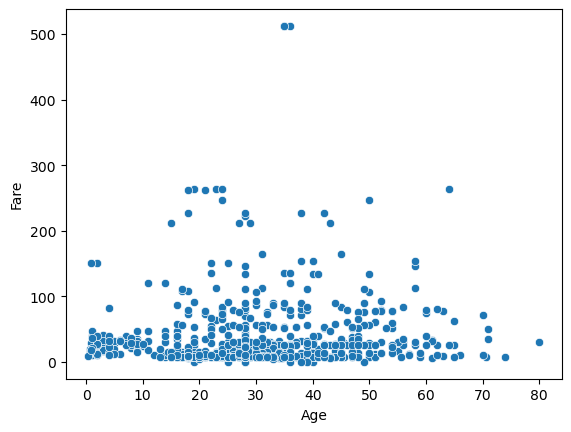

In [180]:
sns.scatterplot( x = "Age", y = "Fare", data = df)

plt.show()

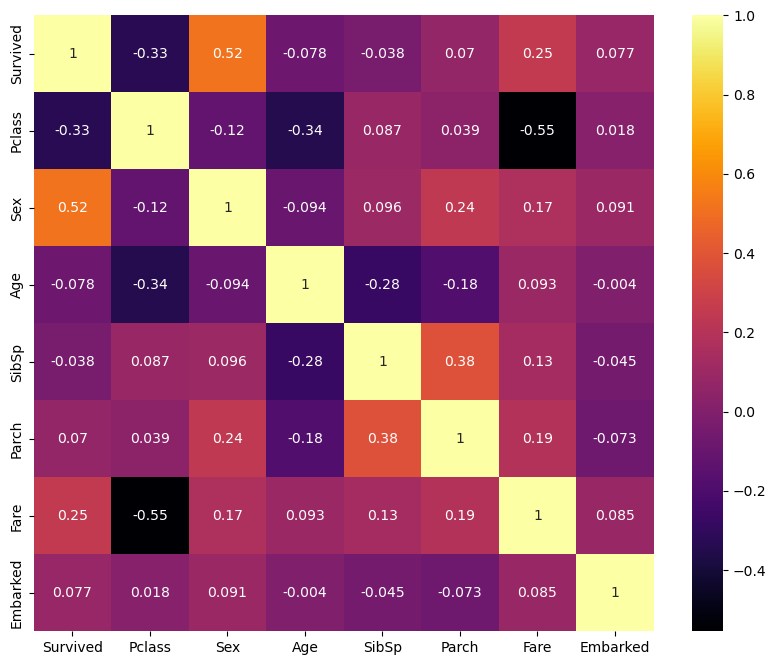

In [184]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),
            annot = True,
            cmap='inferno')

plt.show()

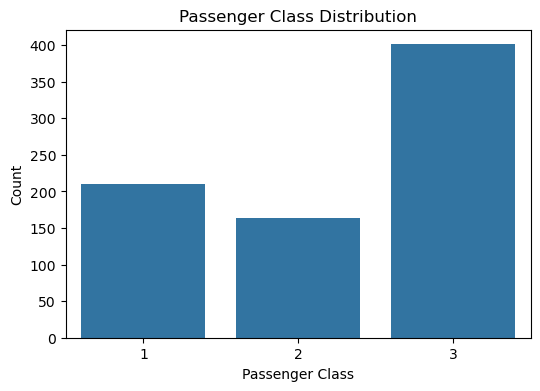

In [186]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data =df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

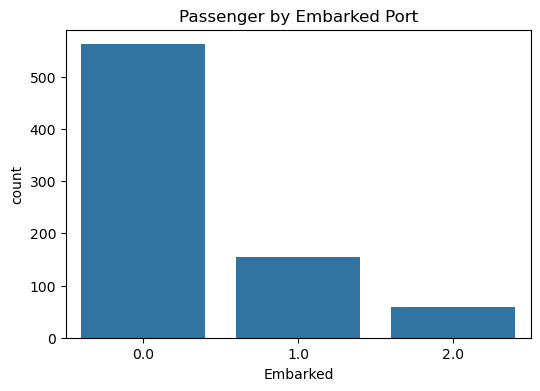

In [188]:
plt.figure(figsize=(6,4))
sns.countplot(x="Embarked", data =df)

plt.title("Passenger by Embarked Port")
plt.show()

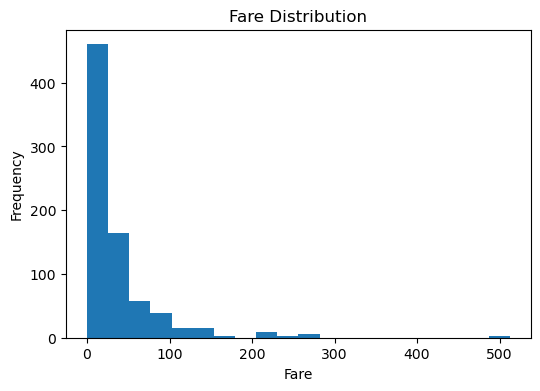

In [192]:
plt.figure(figsize=(6,4))
plt.hist(df["Fare"], bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

In [198]:
X = df.drop("Survived", axis = 1)
y = df["Survived"]

In [205]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[["Age", "Fare"]] = scaler.fit_transform(X[["Age", "Fare"]])

In [207]:
X.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,-0.551060,1,0,-0.527515,0.0
1,1,1,0.611945,1,0,0.695086,1.0
2,3,1,-0.260308,0,0,-0.514627,0.0
3,1,1,0.393881,1,0,0.347909,0.0
4,3,0,0.393881,0,0,-0.512240,0.0
5,3,0,-0.114933,0,0,-0.504444,2.0
6,1,0,1.774949,0,0,0.324281,0.0
7,3,0,-2.004815,3,1,-0.263551,0.0
8,3,1,-0.187621,0,2,-0.453370,0.0
9,2,1,-1.132562,1,0,-0.091793,1.0


In [215]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state = 42)

In [217]:
print("Training Data: ", X_train.shape)

print("Testing Data: ", X_test.shape)

Training Data:  (620, 7)
Testing Data:  (155, 7)


In [219]:
print(X_train.head())

     Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
143       3    0 -0.769123      0      0 -0.537061       2.0
862       1    1  1.338822      0      0 -0.170869       0.0
57        3    0 -0.078589      0      0 -0.527912       1.0
448       3    1 -1.786751      2      1 -0.298238       1.0
768       3    0 -0.114933      1      0 -0.204840       2.0


In [221]:
import warnings
warnings.filterwarnings("ignore")
